# XGBoost Model Decision Analysis

This notebook analyzes the trained XGBoost model for CCS prediction:
- Feature importance analysis
- Tree structure visualization
- SHAP value analysis for comprehensive feature impact understanding

In [31]:
import importlib.util
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path

from xgboost import plot_tree, plot_importance
import shap

# Resolve repo root and import Utils from local utils.py (avoid pip package named 'utils').
repo_root = Path.cwd()
if not (repo_root / "utils.py").exists() and (repo_root.parent.parent / "utils.py").exists():
    repo_root = repo_root.parent.parent
elif not (repo_root / "utils.py").exists() and (Path.cwd() / "../../utils.py").resolve().exists():
    repo_root = (Path.cwd() / "../..").resolve()

utils_path = repo_root / "utils.py"
if not utils_path.exists():
    raise FileNotFoundError(f"Could not find local utils.py at {utils_path}")

spec = importlib.util.spec_from_file_location("ccs_local_utils", utils_path)
utils_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(utils_module)
Utils = utils_module.Utils

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 1.5,               # Thicker axis lines
    "axes.spines.top": False,            # Remove top spine
    "axes.spines.right": False,          # Remove right spine
    "xtick.major.width": 1.5,            # Match tick thickness to axis
    "ytick.major.width": 1.5,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

# Load Model and Prepare Data

In [32]:
# Load the trained model
model = joblib.load('ccsbase2.joblib')
print(f"Model loaded successfully")
print(f"Number of estimators: {model.n_estimators}")
print(f"Max depth: {model.max_depth}")
print(f"Learning rate: {model.learning_rate}")

Model loaded successfully
Number of estimators: 6000
Max depth: 10
Learning rate: 0.03


# Rebuild the final feature list used by model

In [33]:
# Get the adduct list (same as used during training)
DB_PATH = "../../datasets/CCSMLDatabase.db"

conn = sqlite3.connect(DB_PATH)
query = "SELECT adduct FROM master_clean GROUP BY adduct HAVING COUNT(*) >= 100 ORDER BY adduct"
adducts = sorted(pd.read_sql_query(query, conn).to_numpy().tolist())
adducts = [adduct[0] for adduct in adducts]
conn.close()

print(f"Number of adducts: {len(adducts)}")
print(f"Adducts: {adducts}")

Number of adducts: 10
Adducts: ['[M+Cl]-', '[M+H-H2O]+', '[M+HCOO]-', '[M+H]+', '[M+K]+', '[M+NH4]+', '[M+Na-2H]-', '[M+Na]+', '[M-H]-', '[M]+']


In [34]:
# Load test data and build features using Utils (same as train.py)
test_df = pd.read_csv('../../pretrained/test_data.csv')
print(f"Test data shape: {test_df.shape}")

utils = Utils()

# Calculate features for test data using the same function as training
X_list = []
y_list = []
valid_indices = []

for idx, row in test_df.iterrows():
    feat_values = utils.calculate_descriptors(
        row['smi'], row['mass'], row['z'], adducts, row['adduct']
    )
    if feat_values is not None:
        X_list.append(feat_values)
        y_list.append(row['ccs'])
        valid_indices.append(idx)

X_test = np.array(X_list)
y_test = np.array(y_list)

print(f"Valid test samples: {len(X_test)}")
print(f"Feature vector length: {X_test.shape[1]}")

Test data shape: (9749, 8)
Valid test samples: 9749
Feature vector length: 1039


In [35]:
# Feature names matching calculate_descriptors output order
feature_names = [
    'MolecularWeight',      # Index 0: Exact molecular weight
    'AdductMass',           # Index 1: ion_mass - MolecularWeight
    'Charge',               # Index 2: Ion charge state (z)
    'LabuteASA',            # Index 3: Labute accessible surface area
]

# Adduct one-hot encoding (Index 4 to 4+len(adducts)-1)
feature_names += [f'Adduct_{a}' for a in adducts]

# Unknown adduct flag (Index 4+len(adducts))
feature_names.append('Adduct_Other')

# Morgan fingerprint bits (Index 4+len(adducts)+1 to end)
feature_names += [f'MorganFP_{i}' for i in range(1024)]

print(f"Total features: {len(feature_names)}")
print(f"\nBreakdown:")
print(f"  [0-3]       Molecular properties: 4")
print(f"  [4-{4+len(adducts)-1}]      Adduct encoding: {len(adducts)}")
print(f"  [{4+len(adducts)}]        Adduct_Other: 1")
print(f"  [{4+len(adducts)+1}-{len(feature_names)-1}]  Morgan fingerprints: 1024")

Total features: 1039

Breakdown:
  [0-3]       Molecular properties: 4
  [4-13]      Adduct encoding: 10
  [14]        Adduct_Other: 1
  [15-1038]  Morgan fingerprints: 1024


## 2. Feature Importance Analysis

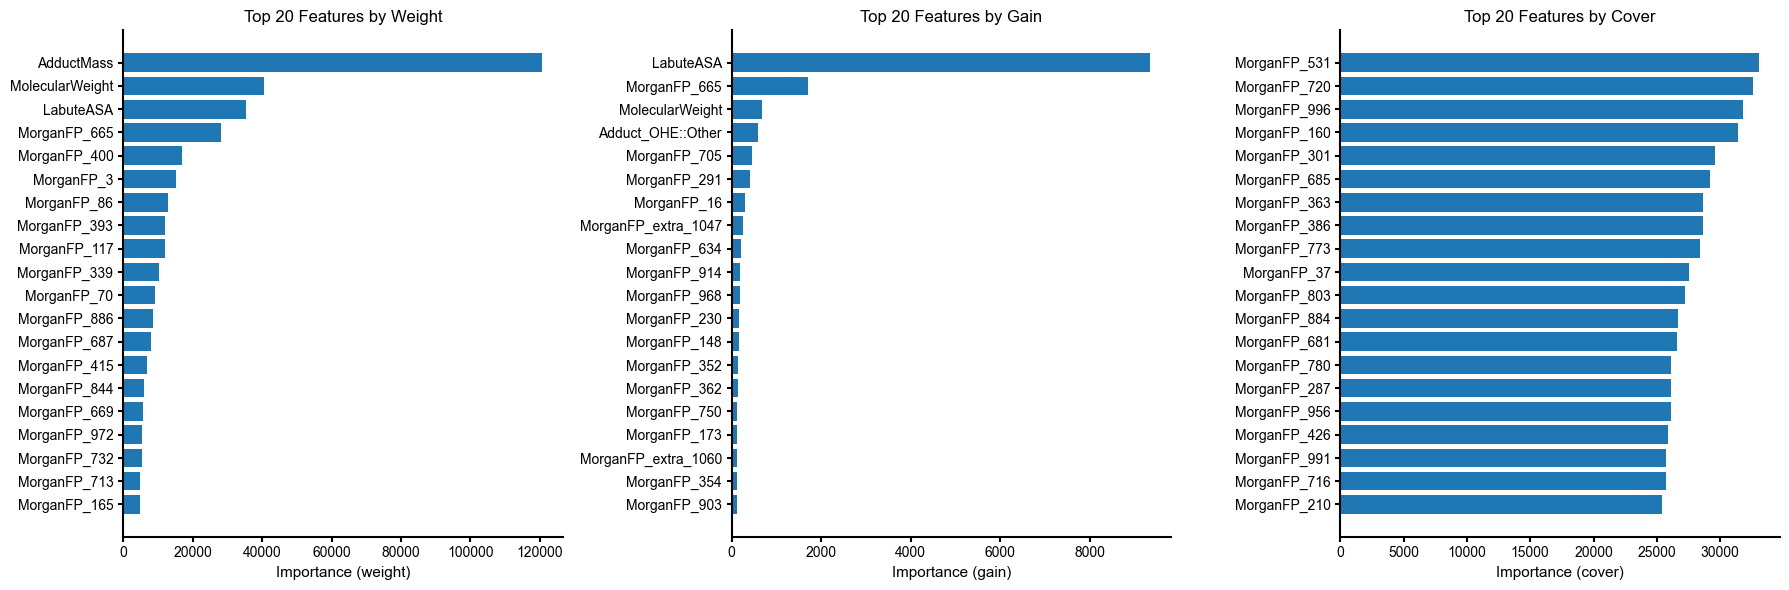

In [36]:
# Get feature importances from model using the rebuilt feature_names
importance_types = ['weight', 'gain', 'cover']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type in zip(axes, importance_types):
    importance = model.get_booster().get_score(importance_type=imp_type)
    
    # Convert to dataframe and sort
    imp_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=True).tail(20)
    
    # Map feature indices (f0, f1, ...) to readable feature groups.
    # This also handles legacy models where fingerprint length > 1024.
    def get_feature_name(x):
        if not x.startswith('f'):
            return x
        idx = int(x[1:])
        core_features = ['MolecularWeight', 'AdductMass', 'Charge', 'LabuteASA']
        adduct_start = 4
        adduct_end = adduct_start + len(adducts)
        adduct_other_idx = adduct_end
        fp_start = adduct_other_idx + 1

        if idx < len(core_features):
            return f'{core_features[idx]}'
        if adduct_start <= idx < adduct_end:
            return f'Adduct_OHE::{adducts[idx - adduct_start]}'
        if idx == adduct_other_idx:
            return 'Adduct_OHE::Other'
        if idx >= fp_start:
            fp_idx = idx - fp_start
            if fp_idx < 1024:
                return f'MorganFP_{fp_idx}'
            return f'MorganFP_extra_{fp_idx}'
        return f'Unmapped_{x}'
    
    imp_df['feature_name'] = imp_df['feature'].apply(get_feature_name)
    
    ax.barh(imp_df['feature_name'], imp_df['importance'])
    ax.set_xlabel(f'Importance ({imp_type})')
    ax.set_title(f'Top 20 Features by {imp_type.capitalize()}')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Create comprehensive importance table using feature_names
all_features = set()
for imp_type in importance_types:
    importance = model.get_booster().get_score(importance_type=imp_type)
    all_features.update(importance.keys())

def get_feature_name(feat):
    """Map XGBoost feature index (f0, f1, ...) to actual feature name."""
    if feat.startswith('f'):
        idx = int(feat[1:])
        return feature_names[idx] if idx < len(feature_names) else feat
    return feat

importance_data = []
for feat in all_features:
    row_data = {
        'feature_idx': feat,
        'feature_name': get_feature_name(feat)
    }
    for imp_type in importance_types:
        importance = model.get_booster().get_score(importance_type=imp_type)
        row_data[imp_type] = importance.get(feat, 0)
    importance_data.append(row_data)

importance_df = pd.DataFrame(importance_data)
importance_df = importance_df.sort_values('gain', ascending=False)

print("Top 30 Features by Gain:")
importance_df.head(30)

Top 30 Features by Gain:


,feature_idx,feature_name,weight,gain,cover
698,f3,LabuteASA,35381.0,9354.338867,1870.579102
777,f680,MorganFP_665,28176.0,1699.771851,1774.635132
357,f0,MolecularWeight,40684.0,675.154541,1144.336304
68,f14,Adduct_Other,90.0,578.341309,24085.900391
969,f720,MorganFP_705,186.0,464.285858,9422.688477
940,f306,MorganFP_291,61.0,399.128510,5694.393555
764,f31,MorganFP_16,3295.0,294.892822,559.169678
146,f1062,f1062,205.0,261.836121,8149.600098
286,f649,MorganFP_634,1789.0,198.864334,2605.556152
832,f929,MorganFP_914,61.0,189.225662,18424.179688


## 3. Tree Structure Visualization

In [38]:
# Export tree for interactive viewing
# Requires: brew install graphviz

try:
    from xgboost import to_graphviz
    
    # Export as SVG (infinite zoom in browser)
    tree_graph = to_graphviz(model, num_trees=0, rankdir='TB')
    tree_graph.format = 'svg'
    tree_graph.render('tree_0', cleanup=True)
    
    # Also export as PDF for high-quality viewing
    tree_graph.format = 'pdf'
    tree_graph.render('tree_0_pdf', cleanup=True)
    
    print("Exported: tree_0.svg and tree_0_pdf.pdf")
    print("\nViewing options:")
    print("  - Browser: Open SVG, Ctrl+scroll to zoom")
    print("  - Figma/Miro/draw.io: Import SVG for infinite whiteboard")
    
except Exception as e:
    print(f"Graphviz not available: {e}")
    print("\nInstall with: brew install graphviz")
    print("\nFallback: Exporting tree as text...")
    
    # Text-based tree dump as fallback
    tree_dump = model.get_booster().get_dump(dump_format='text')[0]
    
    # Save to file
    with open('tree_0_text.txt', 'w') as f:
        f.write(tree_dump)
    print("Exported tree structure to: tree_0_text.txt")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


Exported: tree_0.svg and tree_0_pdf.pdf

Viewing options:
  - Browser: Open SVG, Ctrl+scroll to zoom
  - Figma/Miro/draw.io: Import SVG for infinite whiteboard


In [39]:
# Export first few trees as SVG files for interactive viewing
from xgboost import to_graphviz

num_trees_to_export = 3  # Reduce number since trees are large

for tree_idx in range(num_trees_to_export):
    tree_graph = to_graphviz(model, num_trees=tree_idx, rankdir='TB')
    tree_graph.format = 'svg'
    tree_graph.render(f'tree_{tree_idx}', cleanup=True)
    print(f"Exported tree_{tree_idx}.svg")

print(f"\nOpen SVG files in browser for interactive zoom/pan")
print("Or use tools like Figma, Miro, or draw.io to import SVGs")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


Exported tree_0.svg


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


Exported tree_1.svg


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


Exported tree_2.svg

Open SVG files in browser for interactive zoom/pan
Or use tools like Figma, Miro, or draw.io to import SVGs


In [40]:
# Get tree statistics
booster = model.get_booster()
trees_df = booster.trees_to_dataframe()

# Map feature indices to names in the trees dataframe
trees_df['FeatureName'] = trees_df['Feature'].apply(
    lambda x: feature_names[int(x[1:])] if x.startswith('f') and int(x[1:]) < len(feature_names) else x
)

print(f"Total nodes across all trees: {len(trees_df)}")
print(f"\nTop 20 most used features in splits:")
print(trees_df['FeatureName'].value_counts().head(20))

Total nodes across all trees: 1650476

Top 20 most used features in splits:
FeatureName
Leaf               828238
AdductMass         120557
MolecularWeight     40684
LabuteASA           35381
MorganFP_665        28176
MorganFP_400        16942
MorganFP_3          15126
MorganFP_86         13001
MorganFP_393        12108
MorganFP_117        12096
MorganFP_339        10340
MorganFP_70          9267
MorganFP_886         8714
MorganFP_687         7958
MorganFP_415         6935
MorganFP_844         6152
MorganFP_669         5764
MorganFP_972         5432
MorganFP_732         5367
MorganFP_713         4988
Name: count, dtype: int64


In [41]:
# # Analyze tree depth distribution
# depth_stats = trees_df.groupby('Tree')['Depth'].max()

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.hist(depth_stats, bins=20, edgecolor='black')
# ax.set_xlabel('Max Tree Depth')
# ax.set_ylabel('Count')
# ax.set_title('Distribution of Tree Depths')
# plt.savefig('tree_depth_distribution.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"Mean max depth: {depth_stats.mean():.2f}")
# print(f"Std max depth: {depth_stats.std():.2f}")

## 4. SHAP Value Analysis

In [42]:
# Create SHAP values using a robust path for XGBoost compatibility.
# Important: use numeric arrays (not DataFrame feature names), because adduct names contain
# brackets like [M+H]+ and XGBoost rejects those as DMatrix feature names.
import xgboost as xgb

sample_size = min(1000, len(X_test))
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = np.asarray(X_test[sample_indices], dtype=float)
y_sample = y_test[sample_indices]

print(f"Computing SHAP values for {sample_size} samples...")
shap_backend = None

try:
    explainer = shap.TreeExplainer(model)
    shap_exp = explainer(X_sample, check_additivity=False)
    shap_values = np.asarray(shap_exp.values)
    base_values = np.asarray(shap_exp.base_values)
    shap_backend = "treeexplainer"
    print("SHAP backend: shap.TreeExplainer")
except Exception as e:
    print(f"TreeExplainer failed ({type(e).__name__}: {e})")
    print("Falling back to native XGBoost pred_contribs...")

    booster = model.get_booster() if hasattr(model, "get_booster") else model
    dmat = xgb.DMatrix(X_sample)
    contrib = booster.predict(dmat, pred_contribs=True, validate_features=False)

    shap_values = contrib[:, :-1]
    base_values = contrib[:, -1]
    shap_exp = shap.Explanation(
        values=shap_values,
        base_values=base_values,
        data=X_sample,
        feature_names=feature_names,
    )
    shap_backend = "xgb_pred_contribs"
    print("SHAP backend: xgboost pred_contribs")

print(f"SHAP values computed. Shape: {shap_values.shape}")

Computing SHAP values for 1000 samples...
TreeExplainer failed (ValueError: feature_names must be string, and may not contain [, ] or <)
Falling back to native XGBoost pred_contribs...


ValueError: feature_names must be string, and may not contain [, ] or <

In [ ]:
# SHAP Summary Plot (bar)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=30,
    show=False,
)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SHAP Beeswarm Plot (shows direction of feature impact)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=30,
    show=False,
)
plt.title('SHAP Summary (Beeswarm)')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SHAP Dependence Plots for top features
# Calculate mean absolute SHAP for ranking features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_indices = np.argsort(mean_abs_shap)[-6:][::-1]

print("Top 6 features by mean |SHAP|:")
for i, idx in enumerate(top_feature_indices):
    print(f"  {i+1}. {feature_names[idx]}: {mean_abs_shap[idx]:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat_idx in enumerate(top_feature_indices):
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_sample,
        feature_names=feature_names,
        ax=axes[i],
        show=False,
    )

plt.tight_layout()
plt.savefig('shap_dependence_top6.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SHAP Waterfall plot for a single prediction
# Show how each feature contributes to a specific prediction
sample_idx = 0

single_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=(float(base_values[sample_idx]) if np.ndim(base_values) > 0 else float(base_values)),
    data=X_sample[sample_idx],
    feature_names=feature_names,
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(single_exp, max_display=20, show=False)
plt.title(f'SHAP Waterfall for Sample {sample_idx}')
plt.tight_layout()
plt.savefig('shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Force plot for a single sample
shap.initjs()

base0 = float(base_values[0]) if np.ndim(base_values) > 0 else float(base_values)
shap.force_plot(
    base0,
    shap_values[0],
    X_sample[0],
    feature_names=feature_names,
)

## 5. Grouped Feature Analysis

In [ ]:
# Group features and analyze importance by category
# Using adducts list from setup to define correct index ranges
n_adducts = len(adducts)

feature_groups = {
    'Molecular Properties': [0, 1, 2, 3],  # MolecularWeight, AdductMass, Charge, LabuteASA
    'Adduct Encoding': list(range(4, 4 + n_adducts + 1)),  # adducts + Adduct_Other
    'Morgan Fingerprints': list(range(4 + n_adducts + 1, len(feature_names)))  # 1024 bits
}

print("Feature group index ranges:")
for group, indices in feature_groups.items():
    print(f"  {group}: [{indices[0]}:{indices[-1]}] ({len(indices)} features)")

group_importance = {}
for group_name, indices in feature_groups.items():
    group_shap = np.abs(shap_values[:, indices]).mean()
    group_importance[group_name] = group_shap

# Plot grouped importance
fig, ax = plt.subplots(figsize=(10, 5))
groups = list(group_importance.keys())
values = list(group_importance.values())

bars = ax.bar(groups, values, color=['#2ecc71', '#3498db', '#9b59b6'])
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Feature Group Importance')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('grouped_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Group Importance:")
for group, imp in group_importance.items():
    print(f"  {group}: {imp:.4f}")

In [ ]:
# Analyze top Morgan fingerprint bits
# Fingerprints start after molecular properties (4) + adducts (n_adducts) + Adduct_Other (1)
fp_start = 4 + len(adducts) + 1
fp_shap = np.abs(shap_values[:, fp_start:]).mean(axis=0)

top_fp_indices = np.argsort(fp_shap)[-20:][::-1]

print(f"Morgan fingerprints: indices [{fp_start}:{len(feature_names)-1}]")
print(f"\nTop 20 Morgan Fingerprint Bits by SHAP Importance:")
for i, idx in enumerate(top_fp_indices):
    print(f"  {i+1}. MorganFP_{idx}: {fp_shap[idx]:.4f}")

# Plot top fingerprint bits
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(20), [fp_shap[i] for i in top_fp_indices])
ax.set_xticks(range(20))
ax.set_xticklabels([f'Bit {i}' for i in top_fp_indices], rotation=45, ha='right')
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Top 20 Morgan Fingerprint Bits')
plt.tight_layout()
plt.savefig('top_fingerprint_bits.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Interactions

In [ ]:
# Compute SHAP interaction values (computationally expensive)
# Only available from TreeExplainer backend.
interaction_sample_size = min(200, len(X_sample))
X_interaction = X_sample[:interaction_sample_size]

print(f"Computing SHAP interaction values for {interaction_sample_size} samples...")
print("(This may take a while)")

# Get top 10 feature indices for interaction analysis
top_n = 10
top_indices = np.argsort(mean_abs_shap)[-top_n:][::-1]

print(f"\nTop {top_n} features for interaction analysis:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. {feature_names[idx]}")

if shap_backend == "treeexplainer":
    shap_interaction = explainer.shap_interaction_values(X_interaction)
    print("\nInteraction values computed.")
else:
    shap_interaction = None
    print("\nSkipping interaction values: not supported for pred_contribs fallback backend.")

In [ ]:
# Interaction heatmap for top features
if shap_interaction is None:
    print("No interaction heatmap generated because interaction values were skipped.")
else:
    interaction_matrix = np.abs(shap_interaction[:, top_indices, :][:, :, top_indices]).mean(axis=0)

    top_feature_names_list = [feature_names[i] for i in top_indices]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(interaction_matrix, cmap='YlOrRd')
    ax.set_xticks(range(len(top_indices)))
    ax.set_yticks(range(len(top_indices)))
    ax.set_xticklabels(top_feature_names_list, rotation=45, ha='right')
    ax.set_yticklabels(top_feature_names_list)
    plt.colorbar(im, label='Mean |Interaction Value|')
    ax.set_title('SHAP Interaction Values (Top 10 Features)')
    plt.tight_layout()
    plt.savefig('shap_interaction_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Summary

In [ ]:
# Generate summary report
print("=" * 60)
print("XGBoost Model Analysis Summary")
print("=" * 60)

print(f"\nModel Configuration:")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Max depth: {model.max_depth}")
print(f"  - Learning rate: {model.learning_rate}")
print(f"  - Total features: {len(feature_names)}")
print(f"  - Adducts used: {len(adducts)}")

print(f"\nFeature Breakdown:")
print(f"  - Molecular properties: 4 (MolecularWeight, AdductMass, Charge, LabuteASA)")
print(f"  - Adduct encoding: {len(adducts) + 1} ({len(adducts)} adducts + Other)")
print(f"  - Morgan fingerprints: 1024")

print(f"\nTop 10 Most Important Features (by SHAP):")
top_10_indices = np.argsort(mean_abs_shap)[-10:][::-1]
for i, idx in enumerate(top_10_indices):
    print(f"  {i+1}. {feature_names[idx]}: {mean_abs_shap[idx]:.4f}")

print(f"\nFeature Group Contributions:")
total_importance = sum(group_importance.values())
for group, imp in group_importance.items():
    pct = (imp / total_importance) * 100
    print(f"  - {group}: {pct:.1f}%")

print("\n" + "=" * 60)